# Day 03：残差连接的直觉 —— "抄近道"的艺术> 🌉 第七周 · ResNet 的奇迹 · 第 3 天前两天我们见证了退化问题的可怕：网络越深越蠢，信息在传递中走样。今天，我们要认识那个打破僵局的天才想法——**残差连接（Residual Connection）**，也叫**跳跃连接（Skip Connection）**。这个想法简单到令人发指，却改变了整个深度学习的历史。**今天的任务**：1. 用生活隐喻理解残差连接的核心思想2. 从数学直觉理解为什么 F(x) + x 比 H(x) 更容易学3. 用代码验证：加一条"近道"，退化问题就消失了---

## 1. 历史剧场：何恺明的灵光一闪2015 年，何恺明在微软亚洲研究院面对退化问题苦思冥想。他问了自己一个关键问题：> 如果浅层网络已经学到了不错的特征，那在它后面加更多层时，**最差的情况**应该是什么？答案显而易见：**最差的情况是，新加的层什么都不做，直接把输入原封不动地传过去**。这样，深层网络至少不会比浅层网络差。但问题是：普通网络没有"什么都不做"这个选项。每一层都必须学一个从输入到输出的完整映射 H(x)，它要么学对，要么学错——没有"躺平"的选择。何恺明的天才之处在于：**他改变了网络要学习的目标**。不再让网络学 H(x)，而是让它学 **H(x) - x**，也就是"输出和输入之间的差值"——**残差（Residual）**。然后，把残差加回输入上：**F(x) + x = H(x)**这样一来，如果某一层"什么都不想做"，它只需要学 **F(x) = 0**，输出就自动等于输入 x。学 0 比学一个复杂的恒等映射容易太多了！---

## 2. 生活隐喻：三种理解残差连接的方式### 隐喻一：修改图纸 vs 从零画图想象你是一个建筑设计师：- **普通网络**：每一层都要从零画出完整的建筑图纸（H(x)）- **残差网络**：你拿到上一版的图纸（x），只需要在上面标注"这里改一下"（F(x)），然后合并出最终版（F(x) + x）标注修改比从零画图容易多了！如果不需要修改，标注"无改动"就行——这就是 F(x) = 0。### 隐喻二：抄近道想象你在爬山：- **普通网络**：必须沿着蜿蜒的山路一层一层往上爬，每一步都可能走错- **残差网络**：每隔一段路就有一条"近道"（跳跃连接），可以直接跳到更高处即使中间某一段路走错了，近道也能保证你至少到达了上一段路的终点——不会越走越低。### 隐喻三：增量学习想象你在写文章：- **普通网络**：每一层都要重写整篇文章- **残差网络**：每一层只需要写"修改意见"，然后叠加到原文上如果某一层觉得原文已经够好了，它只需要写"无修改"——F(x) = 0。---

<p align="center">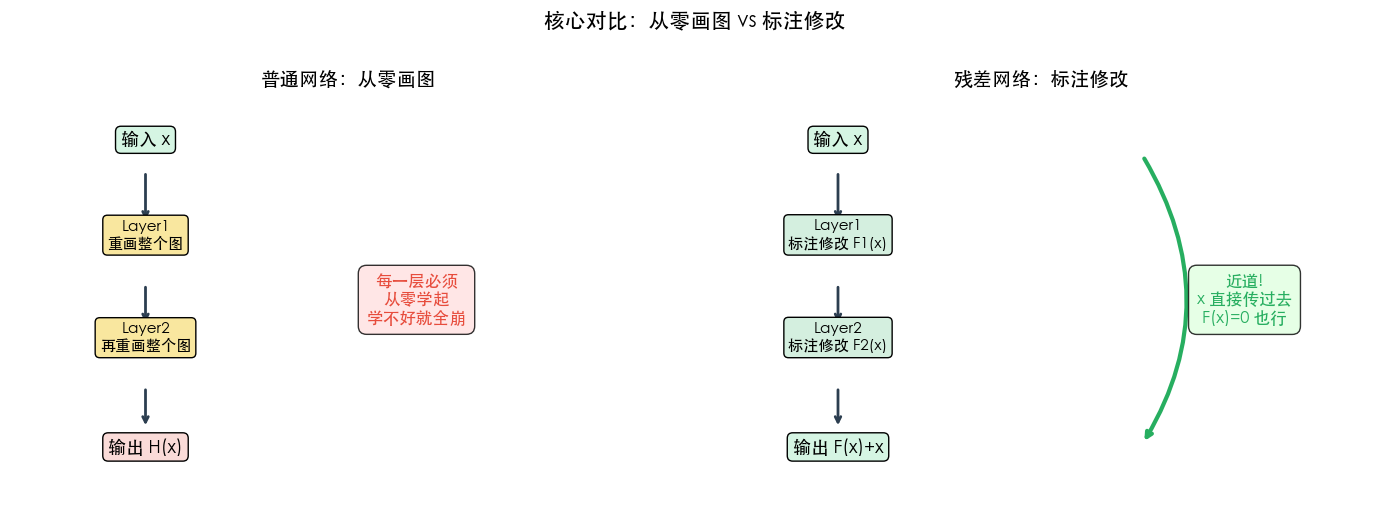</p>*普通网络 vs 残差网络 信息流对比图*

## 3. 几何直觉：为什么学"差值"比学"全部"更容易？让我们用一个简单的例子来建立直觉。假设我们希望网络学到一个恒等映射：输出 = 输入（H(x) = x）### 普通网络：学 H(x) = x网络需要学到的权重组合，恰好让输出等于输入。在全连接层中，这意味着权重矩阵要恰好是单位矩阵——这是一个非常精确的约束，很难通过梯度下降恰好学到。### 残差网络：学 F(x) = H(x) - x = 0网络只需要让 F(x) 输出 0——把所有权重初始化为接近 0 就行了！梯度下降很容易把权重推向 0。

In [ ]:
import torchimport torch.nn as nnimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 3.1 直觉实验：学恒等映射

In [ ]:
torch.manual_seed(42)x_target = torch.randn(100, 4)identity_target = x_target.clone()class PlainLayer(nn.Module):    """普通层：学完整映射 H(x)"""    def __init__(self, size):        super().__init__()        self.linear = nn.Linear(size, size)    def forward(self, x):        return self.linear(x)class ResidualLayer(nn.Module):    """残差层：学残差 F(x)，输出 F(x) + x"""    def __init__(self, size):        super().__init__()        self.linear = nn.Linear(size, size)    def forward(self, x):        return self.linear(x) + xdef train_layer(model, x, target, epochs=500, lr=0.01):    optimizer = torch.optim.Adam(model.parameters(), lr=lr)    loss_fn = nn.MSELoss()    losses = []    for epoch in range(epochs):        output = model(x)        loss = loss_fn(output, target)        optimizer.zero_grad()        loss.backward()        optimizer.step()        losses.append(loss.item())    return lossesplain_layer = PlainLayer(4)residual_layer = ResidualLayer(4)plain_losses = train_layer(plain_layer, x_target, identity_target)residual_losses = train_layer(residual_layer, x_target, identity_target)fig, ax = plt.subplots(1, 1, figsize=(8, 5))ax.plot(plain_losses, label='普通层: 学 H(x) = x', color='#e74c3c', alpha=0.8)ax.plot(residual_losses, label='残差层: 学 F(x) = 0', color='#2ecc71', alpha=0.8)ax.set_xlabel('Epoch', fontsize=12)ax.set_ylabel('MSE Loss', fontsize=12)ax.set_title('学恒等映射：残差层轻松碾压普通层', fontsize=14)ax.legend(fontsize=12)ax.grid(True, alpha=0.3)ax.set_yscale('log')plt.tight_layout()plt.show()

### 解读- **普通层**（红色）：学 H(x) = x 很困难，损失下降缓慢- **残差层**（绿色）：学 F(x) = 0 很容易，损失快速降到接近 0这就是残差连接的核心优势：**把"学恒等映射"这个难题，变成了"学零"这个简单任务**。---

## 4. 代码实验室：一条"近道"治百病现在让我们回到昨天的同心圆数据，看看加上残差连接后，深层网络是否还能正常训练。

In [ ]:
def make_circles_data(n_samples=500, noise=0.05):    np.random.seed(42)    n = n_samples // 2    theta_outer = np.random.uniform(0, 2 * np.pi, n)    theta_inner = np.random.uniform(0, 2 * np.pi, n)    r_outer = 1.0 + np.random.randn(n) * noise    r_inner = 0.5 + np.random.randn(n) * noise    x_outer = np.column_stack([r_outer * np.cos(theta_outer), r_outer * np.sin(theta_outer)])    x_inner = np.column_stack([r_inner * np.cos(theta_inner), r_inner * np.sin(theta_inner)])    X = np.vstack([x_outer, x_inner]).astype(np.float32)    y = np.concatenate([np.zeros(n), np.ones(n)]).astype(np.float32)    return torch.tensor(X), torch.tensor(y).unsqueeze(1)X_circles, y_circles = make_circles_data()

### 4.1 残差块：只加一行代码

In [ ]:
class ResidualBlock(nn.Module):    """残差块：和普通块唯一的区别就是最后加了 x"""    def __init__(self, hidden_size):        super().__init__()        self.block = nn.Sequential(            nn.Linear(hidden_size, hidden_size),            nn.BatchNorm1d(hidden_size),            nn.ReLU(),            nn.Linear(hidden_size, hidden_size),            nn.BatchNorm1d(hidden_size),        )        self.relu = nn.ReLU()    def forward(self, x):        out = self.block(x)        out = out + x        out = self.relu(out)        return outclass ResidualNet(nn.Module):    """残差网络：用残差块替换普通块"""    def __init__(self, input_size=2, hidden_size=64, num_blocks=4, output_size=1):        super().__init__()        layers = [nn.Linear(input_size, hidden_size), nn.ReLU()]        for _ in range(num_blocks):            layers.append(ResidualBlock(hidden_size))        layers.append(nn.Linear(hidden_size, output_size))        layers.append(nn.Sigmoid())        self.net = nn.Sequential(*layers)    def forward(self, x):        return self.net(x)

注意看 `ResidualBlock.forward` 中的关键一行：

In [ ]:
out = out + x    # 这就是残差连接！

和 `PlainBlock` 唯一的区别就是这一行。但这一行，改变了一切。### 4.2 对比实验：Plain vs Residual

In [ ]:
class PlainBlock(nn.Module):    def __init__(self, hidden_size):        super().__init__()        self.block = nn.Sequential(            nn.Linear(hidden_size, hidden_size),            nn.BatchNorm1d(hidden_size),            nn.ReLU(),            nn.Linear(hidden_size, hidden_size),            nn.BatchNorm1d(hidden_size),        )        self.relu = nn.ReLU()    def forward(self, x):        out = self.block(x)        out = self.relu(out)        return outclass PlainNet(nn.Module):    def __init__(self, input_size=2, hidden_size=64, num_blocks=4, output_size=1):        super().__init__()        layers = [nn.Linear(input_size, hidden_size), nn.ReLU()]        for _ in range(num_blocks):            layers.append(PlainBlock(hidden_size))        layers.append(nn.Linear(hidden_size, output_size))        layers.append(nn.Sigmoid())        self.net = nn.Sequential(*layers)    def forward(self, x):        return self.net(x)

In [ ]:
depth = 16epochs = 300torch.manual_seed(42)plain_deep = PlainNet(num_blocks=depth)optimizer_plain = torch.optim.Adam(plain_deep.parameters(), lr=0.01)loss_fn = nn.BCELoss()plain_losses = []for epoch in range(epochs):    pred = plain_deep(X_circles)    loss = loss_fn(pred, y_circles)    optimizer_plain.zero_grad()    loss.backward()    optimizer_plain.step()    plain_losses.append(loss.item())torch.manual_seed(42)residual_deep = ResidualNet(num_blocks=depth)optimizer_res = torch.optim.Adam(residual_deep.parameters(), lr=0.01)res_losses = []for epoch in range(epochs):    pred = residual_deep(X_circles)    loss = loss_fn(pred, y_circles)    optimizer_res.zero_grad()    loss.backward()    optimizer_res.step()    res_losses.append(loss.item())fig, ax = plt.subplots(1, 1, figsize=(8, 5))ax.plot(plain_losses, label=f'普通深层 ({depth} Blocks)', color='#e74c3c', alpha=0.8)ax.plot(res_losses, label=f'残差深层 ({depth} Blocks)', color='#2ecc71', alpha=0.8)ax.set_xlabel('Epoch', fontsize=12)ax.set_ylabel('Training Loss', fontsize=12)ax.set_title('一条近道的威力：残差连接 vs 普通网络', fontsize=14)ax.legend(fontsize=12)ax.grid(True, alpha=0.3)plt.tight_layout()plt.show()

### 解读- **普通深层网络**（红色）：损失居高不下，训练困难- **残差深层网络**（绿色）：损失快速下降，训练顺畅唯一的区别就是 `out = out + x` 这一行代码。一条"近道"，解决了退化问题。---

## 5. 信息流的几何直觉让我们用图来理解信息在残差网络中是如何流动的：

<p align="center">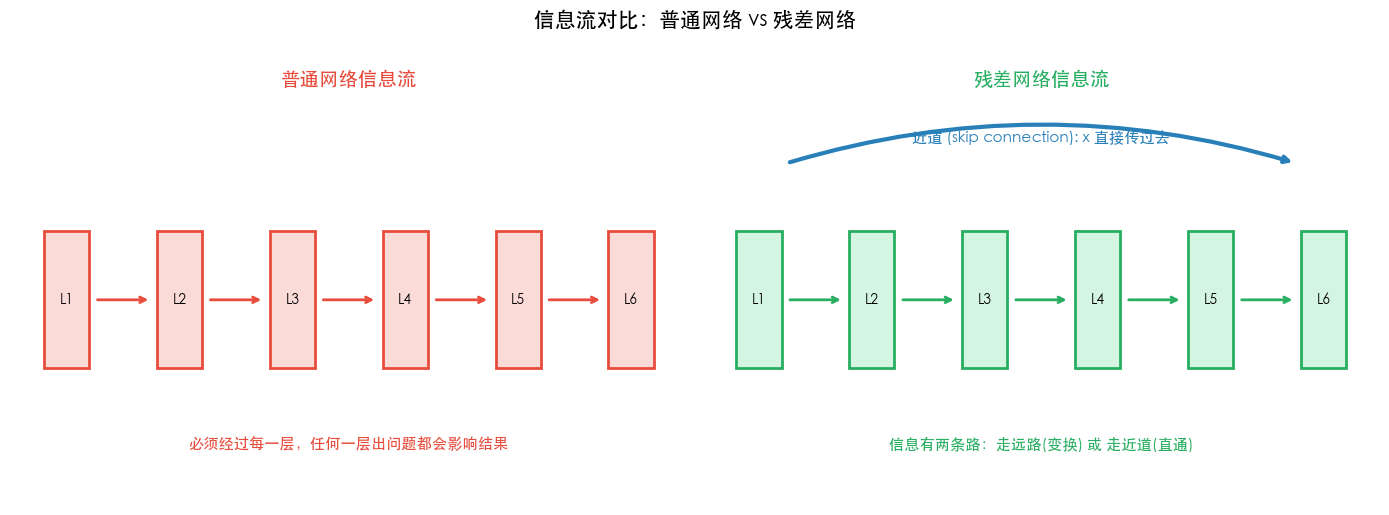</p>*信息流路径对比图*

普通网络的信息流：  x → [Layer1] → [Layer2] → [Layer3] → ... → [LayerN] → 输出       必须经过每一层，任何一层出问题都会影响最终结果残差网络的信息流：  x ─────────────────────────────────────────→ (+) → 输出  │                                            ↑  └→ [Layer1] → [Layer2] → [Layer3] → ... → [LayerN] ─┘  信息有两条路：  1. 走"近道"直接传过去（x）  2. 走"远路"经过各层加工（F(x)）  最终输出 = x + F(x)

**关键洞察**：- 即使所有中间层都"罢工"（F(x) = 0），信息也能通过近道传过去- 中间层只需要学"增量"——对输入的修正- 近道保证了：**深层网络至少不会比浅层网络差**---

## 今日结语今天我们认识了深度学习史上最优雅的发明之一——残差连接。核心思想只有一句话：**不要让网络学完整的映射 H(x)，让它学残差 F(x) = H(x) - x，然后输出 F(x) + x。**这个看似微小的改变，解决了一个看似无解的问题。它让网络从"必须学对"变成了"学不好也没关系，至少不会更差"。明天，我们要亲手写一个完整的 `ResidualBlock`，并深入理解它的每一个细节。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 在图纸上标注修改意见，而非从零画图 | 残差学习：学 F(x) = H(x) - x || 抄近道直接到达目的地 | 跳跃连接 / 残差连接 (Skip Connection) || "无修改"——原文已经够好了 | F(x) = 0，恒等映射 || 增量修改比从零开始容易 | 残差比完整映射更容易学习 || 即使中间层罢工，信息也能传过去 | 残差连接保证深层不差于浅层 || 最终结果 = 原始 + 修改 | H(x) = F(x) + x || 普通层必须学精确的恒等映射 | 普通网络学 H(x) = x 很难 || 残差层只需要学"什么都不改" | 残差网络学 F(x) = 0 很容易 |